In [1]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np
import statsmodels.formula.api as smf


###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study3.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')
os.makedirs(outputdir, exist_ok=True)

#Read in cleaned data 
accomodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accomodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accommodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accommodate columns: ['participant', 'free_texts', 'feedback', 'fertility_score', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.response', 'feet_direction_slider.response', 'feet_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'fertility_score', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_feet', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim', 'irrelevant_dim', 'feet_high', 'color_low', 'color_high', 'feet_low', 'feet_discrete_slider.respon

In [2]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_feet', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['fertility_score'] = df_accommodate['fertility_score'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_accommodate['free_texts'] = df_accommodate['free_texts'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['fertility_score'] = df_predict['fertility_score'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')



In [3]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Combined/explanationcodes/Explanation_Coding_Study3.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = [
    "none",
    "causal_explanation",
    "color",
    "feet",
    "other",
]

for col in coding_cols:
    df_coding[col] = (
        df_coding[col]
        .fillna(0)
        .replace("", 0)
        .astype(int)
    )


# Feature-specific causal indicators
# A tick in "both" means both color and feet are causal
df_coding["causal_color"] = df_coding["color"].eq(1)
df_coding["causal_feet"] = df_coding["feet"].eq(1)


# Another label for type of explanation: "stripes", "feet", "both", or "none"
df_coding["explanation_type"] = np.select(
    [
        df_coding["causal_color"] & df_coding["causal_feet"],
        df_coding["causal_color"],
        df_coding["causal_feet"],
    ],
    [
        "both",
        "color",
        "feet",
    ],
    default="none",
)


# Broad causal flag that there was a causal explanation of any kind
df_coding["has_causal_explanation"] = (
    df_coding["causal_explanation"].eq(1)
    | df_coding["causal_color"]
    | df_coding["causal_feet"]
)



# Merge coding onto accommodate data
df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "explanation_type",
            "has_causal_explanation",
            "causal_color",
            "causal_feet",
        ]
    ],
    on="participant",
    how="left",
    validate="many_to_one",
)


# Participants not in coding file default to no causal explanation
df_accommodate["explanation_type"] = (
    df_accommodate["explanation_type"]
    .fillna("none")
)

boolean_cols = [
    "has_causal_explanation",
    "causal_color",
    "causal_feet",
]

df_accommodate[boolean_cols] = (
    df_accommodate[boolean_cols]
    .fillna(False)
    .astype(bool)
)

In [4]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [5]:
participant_id = 219

row = df_accommodate.loc[
    df_accommodate['participant'] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal feet: {row['causal_feet']}")
print(f"Causal color: {row['causal_color']}")
print("\n--- FREE TEXTS ---\n")

for text in row['free_texts']:
    print(text)
    print()

Participant: 219
Explanation type: both
Has causal explanation: True
Causal feet: True
Causal color: True

--- FREE TEXTS ---

The white stripe on its belly means it is well hydrated.

The green stripe on its neck indicates malnourishment.

The red coloring indicates algae poisoning.

The clear tan color on its chin and belly stripe indicate healthy reproductive function.

The pointy toes indicate frequent stressors in its environment.

The round, evenly colored toes indicate low stress, and the healthy white stripe on its belly indicates good hydration.

Although the pointed toes indicate stress, the bright green coloring and clear belly stripes indicate good overall health otherwise.

The round toes indicate low stress, the clear tan belly stripe indicates good hydration, and the tan chin shows adequate nutrition.

It got unlucky this year...

The pointed toes are a sign of stress, which this one must have a low tolerance for.

The belly stripe and tan chin show good hydration and nu

In [7]:

df_combined = pd.concat(
    [df_accommodate, df_predict],
    ignore_index=True
)

df_combined['participant'] = range(1, len(df_combined) + 1)
participant_rows = []

for _, row in df_combined.iterrows():

    feet_yes = (
        1 if row['feet_discrete_slider.response'] == 'Yes' else 0
    )
    color_yes = (
        1 if row['color_discrete_slider.response'] == 'Yes' else 0
    )

    model_param_score = (
        feet_yes +
        color_yes
    )

    # Create 3-level explanation group
    if row['task'] == 'predict':
        explanation_group = 'predictor'

    elif row['has_causal_explanation'] == True:
        explanation_group = 'causal_explainer'

    else:
        explanation_group = 'non_explainer'

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],
        'explanation_group': explanation_group,
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'overfit': model_param_score == 2,
        'irrelevant_dim': row['irrelevant_dim']
    })

df_params = pd.DataFrame(participant_rows)
df_params.to_csv(
    os.path.join(
        outputdirCombined,
        "df_params_by_explanation_for_R-Study3.csv"
    ),
    index=False
)
contingency = pd.crosstab(
    df_params['explanation_group'],
    df_params['overfit']
)

print("\nContingency table:")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print("\nOmnibus chi-square:")
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

print("\nExpected counts:")
print(
    pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )
)


Contingency table:
overfit            False  True 
explanation_group              
causal_explainer      48     32
non_explainer         74     63
predictor            150     67

Omnibus chi-square:
Chi-square = 8.495
df = 2
p-value = 0.0143

Expected counts:
overfit                 False      True 
explanation_group                       
causal_explainer    50.138249  29.861751
non_explainer       85.861751  51.138249
predictor          136.000000  81.000000


In [6]:
#Create map from short codes to feature descriptions

feet_map = {
    'round': 'f',
    'curly/pointy': 'c'
}

color_map = {
    'red': 'y',
    'green': 'g'
}



feature_maps = {
    'feet': feet_map,
    'color': color_map
}


#Compute feature importance scores

from doctest import debug



def compute_feature_importance_from_df(df):
    """
    Compute numeric feature importance scores(-7 to 7) for each participant,
    based on the saved slider_responses and the feature _high/_low mapping.
    This is computed based on whether a feature was really relevant (positive sign) or irrelevant (negative sign).
    0 = no response or feature was not thought to be relevant
    columns:
      - wings_discrete_slider.response, wings_direction_slider.response, wings_continuous_slider.response
      - color_discrete_slider.response, ...
      - tail_discrete_slider.response, ...
      - wings_high, wings_low, color_high, color_low, tail_high, tail_low
    """
    features = ['feet', 'color']
    
    def compute_row_importance(row, feat):
        disc = row[f'{feat}_discrete_slider.response']
        dirc = row[f'{feat}_direction_slider.response']
        cont = row[f'{feat}_continuous_slider.response']

        #If they said a feature wasn't relevant, then importance is 0
        
        if disc == 'No' or pd.isna(disc):
            return 0.0
        
        # Make sure continuous slider value exists, if not, set it to 0
        cont_val = float(cont) if not pd.isna(cont) else 0.0

        # Get mapping from long to short feature name
        mapping = feature_maps.get(feat, {})

        # Normalize strings: strip whitespace, collapse multiple spaces, lower-case
        def normalize_str(s):
            """Strip leading/trailing whitespace and collapse internal multiple spaces."""

            if isinstance(s, str):
                return " ".join(s.split()).lower()
            return ""
        

        #Name of features need to be normalized for comparison using the mapping
        dirc_norm = normalize_str(dirc)

        #Get internal short code for selected feature direction
        internal_dirc = mapping.get(dirc_norm, None)
        

        high_val = normalize_str(row[f'{feat}_high'])
        low_val  = normalize_str(row[f'{feat}_low'])
        

        
        # Debug print statement (make sure mappings look right)
        debug = True
        if debug:
            print('response:', repr(dirc_norm), 'internal:', repr(internal_dirc), 
                'high:', repr(high_val), 'low:', repr(low_val))
            

        #If they correctly selected the high feature, assign positive sign
        if internal_dirc == high_val:
            sign = 1
        #If they incorrectly selected the low feature, assign negative sign
        elif internal_dirc == low_val:
            if debug:
                print('in negative')
            sign = -1
        else:
            if debug:
                print('in empty')
            sign = 0
            cont_val = 0.0

        # Add sign to continuous value
        importance = cont_val * sign

        return importance

    
    # Compute for each feature
    for feat in features:
        df[f'{feat}_importance'] = df.apply(lambda row: compute_row_importance(row, feat), axis=1)
    
    return df

df_combined = compute_feature_importance_from_df(df_combined)

# Groups:
# predict
# accommodate_none
# accommodate_causal


df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),
        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default=pd.NA,
)


# Reshape to long format:
# one row per participant × feature dimension

cols_to_keep = [
    "participant",
    "task",
    "task_explanation_group",
    "feet_importance",
    "color_importance",
    "explanation_type",
    "has_causal_explanation",
    "causal_feet",
    "causal_color",
    "relevant_dim",
    "irrelevant_dim",
    "feet_high",
    "color_high",
    "feet_discrete_slider.response",
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant",
        "task",
        "task_explanation_group",
        "explanation_type",
        "has_causal_explanation",
        "causal_feet",
        "causal_color",
        "relevant_dim",
        "irrelevant_dim",
        "feet_high",
        "color_high",
        "feet_discrete_slider.response",
    ],
    value_vars=[
        "feet_importance",
        "color_importance",
    ],
    var_name="feature_dimension",
    value_name="feature_importance",
)


# Simplify feature names

df_long["feature_dimension"] = (
    df_long["feature_dimension"]
    .str.replace("_importance", "", regex=False)
)


# Create row-specific indicator:
# Did the participant give a causal explanation for this feature?

df_long["had_causal_explanation_for_feature"] = np.select(
    [
        df_long["feature_dimension"].eq("feet"),
        df_long["feature_dimension"].eq("color"),
    ],
    [
        df_long["causal_feet"].fillna(False),
        df_long["causal_color"].fillna(False),
    ],
    default=False,
).astype(bool)

# Predictors should always be False
df_long["had_causal_explanation_for_feature"] = (
    df_long["had_causal_explanation_for_feature"]
    & df_long["task"].eq("accommodate")
)



response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'f' low: 'c'
in negative
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'round' internal: 'f' high: 'f' low: 'c'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curly/pointy' internal: 'c' high: 'c' low: 'f'
response: 'curl

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/2571023989.py:124: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/2571023989.py:128: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/2571023989.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in 

In [7]:
print(df_long.head())

   participant         task task_explanation_group explanation_type  \
0          183  accommodate       accommodate_none             none   
1           75  accommodate     accommodate_causal             both   
2          100  accommodate     accommodate_causal            color   
3           61  accommodate       accommodate_none             none   
4           97  accommodate     accommodate_causal             both   

  has_causal_explanation causal_feet causal_color relevant_dim irrelevant_dim  \
0                  False       False        False         feet          color   
1                   True        True         True         feet          color   
2                   True       False         True        color           feet   
3                  False       False        False         feet          color   
4                   True        True         True         feet          color   

  feet_high color_high feet_discrete_slider.response feature_dimension  \
0         F 

In [8]:
print(
    df_long.groupby(
        ["feature_dimension", "had_causal_explanation_for_feature"],
        dropna=False,
    ).size()
)

print(
    df_long.loc[
        df_long["participant"].eq(31),
        [
            "participant",
            "task",
            "feature_dimension",
            "causal_color",
            "causal_feet",
            "had_causal_explanation_for_feature",
            "feature_importance"
        ],
    ].sort_values("feature_dimension")
)

feature_dimension  had_causal_explanation_for_feature
color              False                                 372
                   True                                   62
feet               False                                 401
                   True                                   33
dtype: int64
     participant         task feature_dimension causal_color causal_feet  \
598           31  accommodate             color        False       False   
825           31      predict             color          NaN         NaN   
164           31  accommodate              feet        False       False   
391           31      predict              feet          NaN         NaN   

     had_causal_explanation_for_feature  feature_importance  
598                               False                -4.0  
825                               False                 4.0  
164                               False                 6.0  
391                               False                 0.0 

In [9]:
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_by_explanation_for_R-Study3.csv'), index=False)

In [10]:
# Features included in the overfitting/relevance count
features = ["feet", "color"]

discrete_cols = [
    f"{feat}_discrete_slider.response"
    for feat in features
]

# Inspect the response values before recoding
for col in discrete_cols:
    print(f"\nValues in {col}:")
    print(df_combined[col].value_counts(dropna=False))


Values in feet_discrete_slider.response:
feet_discrete_slider.response
Yes    225
No     209
Name: count, dtype: int64

Values in color_discrete_slider.response:
color_discrete_slider.response
Yes    307
No     127
Name: count, dtype: int64


  explanation_group  n_features_endorsed  n_participants  percentage
0         Predictor                    0              41   18.894009
1         Predictor                    1             109   50.230415
2         Predictor                    2              67   30.875576
3     Non-explainer                    0              15   10.948905
4     Non-explainer                    1              59   43.065693
5     Non-explainer                    2              63   45.985401
6         Explainer                    0               8   10.000000
7         Explainer                    1              40   50.000000
8         Explainer                    2              32   40.000000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/2685459091.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/2685459091.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)


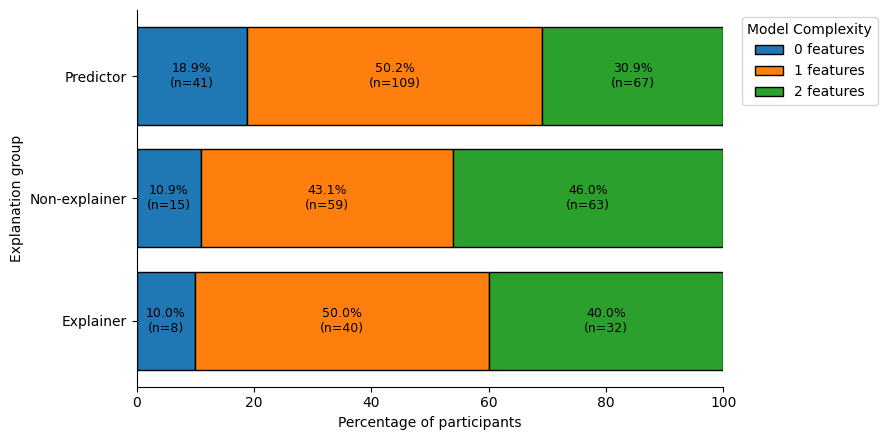

In [11]:
# Convert Yes/No response to 'does this feature matter' into 1/0 indicators
for feat in features:
    response_col = f"{feat}_discrete_slider.response"
    endorsed_col = f"{feat}_endorsed"

    df_combined[endorsed_col] = (
        df_combined[response_col]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# Total number of features judged relevant: 0, 1, or 2
df_combined["n_features_endorsed"] = (
    df_combined["feet_endorsed"]
    + df_combined["color_endorsed"]
)

# Create a new column for explanation group, based on task and causal explanation status
df_combined["explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),

        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),

        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "Predictor",
        "Explainer",
        "Non-explainer",
    ],
    default=pd.NA,
)
# Create a unique identifier for each participant × task combination
df_combined["participant_task_id"] = (
    df_combined["participant"].astype(str)
    + "_"
    + df_combined["task"].astype(str)
)
overfit_df = df_combined[
    [
        "participant",
        "participant_task_id",
        "task",
        "explanation_group",
        "feet_endorsed",
        "color_endorsed",
        "n_features_endorsed",
        "relevant_dim",
        "irrelevant_dim",
    ]
].copy()

# Plotting order
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

score_order = [0, 1, 2]


# Count participants at each score within each group
overfit_percentages = (
    overfit_df
    .dropna(
        subset=[
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .groupby(
        [
            "explanation_group",
            "n_features_endorsed",
        ],
        observed=True
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique"
        )
    )
    .reset_index()
)


# If a group has no participants with a given score, we want to fill in that row with 0 participants
full_index = pd.MultiIndex.from_product(
    [
        group_order,
        score_order,
    ],
    names=[
        "explanation_group",
        "n_features_endorsed",
    ]
)

overfit_percentages = (
    overfit_percentages
    .set_index(
        [
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .reindex(
        full_index,
        fill_value=0
    )
    .reset_index()
)


# Calculate percentage within each explanation group
overfit_percentages["percentage"] = (
    overfit_percentages["n_participants"]
    / overfit_percentages
        .groupby("explanation_group")["n_participants"]
        .transform("sum")
    * 100
)

print(overfit_percentages)

count_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="n_participants"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2], fill_value=0)
    .fillna(0)
)

# Convert long percentages table to wide format:
# one row per group, one column for each score
percentage_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="percentage"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2], fill_value=0)
    .fillna(0)
)


fig, ax = plt.subplots(figsize=(9, 4.5))

left = np.zeros(len(percentage_wide))
#Plot horizontal stacked bar chart
for score in [0, 1, 2]:
    percentages = percentage_wide[score].to_numpy()
    counts = count_wide[score].to_numpy()

    bars = ax.barh(
        y=percentage_wide.index,
        width=percentages,
        left=left,
        edgecolor="black",
        label=f"{score} features",
    )

    for bar, percentage, count, starting_point in zip(
        bars,
        percentages,
        counts,
        left,
    ):
        if percentage >= 8:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=9,
            )
        elif percentage > 0:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += percentages

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("Explanation group")
ax.set_xticks(np.arange(0, 101, 20))
ax.invert_yaxis()

ax.legend(
    title="Model Complexity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

   explanation_group endorsement_pattern  n_participants  percentage
0          Predictor          0 features              41   18.894009
1          Predictor             1: feet              33   15.207373
2          Predictor            1: color              76   35.023041
3          Predictor          2 features              67   30.875576
4      Non-explainer          0 features              15   10.948905
5      Non-explainer             1: feet              17   12.408759
6      Non-explainer            1: color              42   30.656934
7      Non-explainer          2 features              63   45.985401
8          Explainer          0 features               8   10.000000
9          Explainer             1: feet              13   16.250000
10         Explainer            1: color              27   33.750000
11         Explainer          2 features              32   40.000000


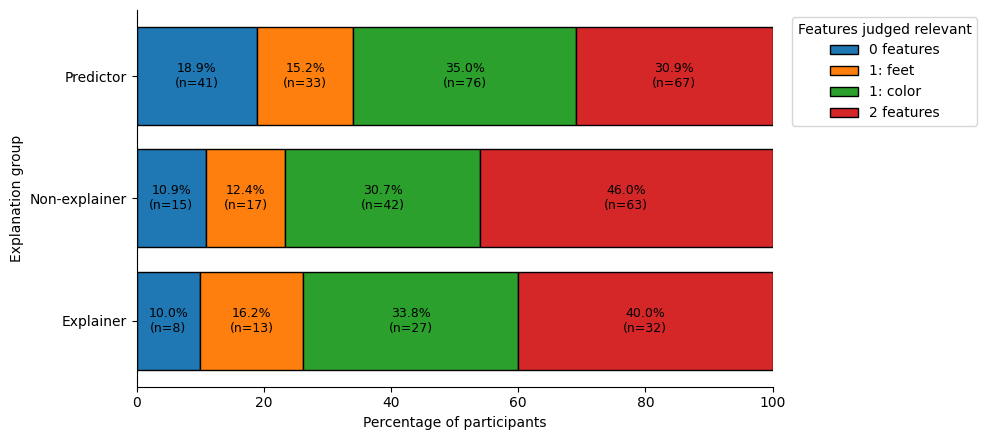

In [13]:
# ---------------------------------------------------------
# Subdivide the "1 feature" category by which feature
# was endorsed
# ---------------------------------------------------------

overfit_df["endorsement_pattern"] = np.select(
    [
        overfit_df["n_features_endorsed"].eq(0),

        (
            overfit_df["n_features_endorsed"].eq(1)
            & overfit_df["feet_endorsed"].eq(1)
        ),

        (
            overfit_df["n_features_endorsed"].eq(1)
            & overfit_df["color_endorsed"].eq(1)
        ),

        overfit_df["n_features_endorsed"].eq(2),
    ],
    [
        "0 features",
        "1: feet",
        "1: color",
        "2 features",
    ],
    default=pd.NA,
)


# Order of groups on the y-axis
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

# Order of segments from left to right
pattern_order = [
    "0 features",
    "1: feet",
    "1: color",
    "2 features",
]


# ---------------------------------------------------------
# Count participants in each endorsement pattern
# ---------------------------------------------------------

pattern_percentages = (
    overfit_df
    .dropna(
        subset=[
            "explanation_group",
            "endorsement_pattern",
        ]
    )
    .groupby(
        [
            "explanation_group",
            "endorsement_pattern",
        ],
        observed=True,
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique",
        )
    )
    .reset_index()
)


# Add missing group × pattern combinations as zeros
full_index = pd.MultiIndex.from_product(
    [
        group_order,
        pattern_order,
    ],
    names=[
        "explanation_group",
        "endorsement_pattern",
    ],
)

pattern_percentages = (
    pattern_percentages
    .set_index(
        [
            "explanation_group",
            "endorsement_pattern",
        ]
    )
    .reindex(
        full_index,
        fill_value=0,
    )
    .reset_index()
)


# Calculate percentages within each explanation group
pattern_percentages["percentage"] = (
    pattern_percentages["n_participants"]
    / pattern_percentages
        .groupby(
            "explanation_group"
        )["n_participants"]
        .transform("sum")
    * 100
)

print(pattern_percentages)


# ---------------------------------------------------------
# Convert counts and percentages to wide format
# ---------------------------------------------------------

count_wide = (
    pattern_percentages
    .pivot(
        index="explanation_group",
        columns="endorsement_pattern",
        values="n_participants",
    )
    .reindex(group_order)
    .reindex(
        columns=pattern_order,
        fill_value=0,
    )
    .fillna(0)
)


percentage_wide = (
    pattern_percentages
    .pivot(
        index="explanation_group",
        columns="endorsement_pattern",
        values="percentage",
    )
    .reindex(group_order)
    .reindex(
        columns=pattern_order,
        fill_value=0,
    )
    .fillna(0)
)


# ---------------------------------------------------------
# Horizontal 100% stacked bar chart
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4.5))

left = np.zeros(len(percentage_wide))

for pattern in pattern_order:
    percentages = percentage_wide[pattern].to_numpy()
    counts = count_wide[pattern].to_numpy()

    bars = ax.barh(
        y=percentage_wide.index,
        width=percentages,
        left=left,
        edgecolor="black",
        label=pattern,
    )

    for bar, percentage, count, starting_point in zip(
        bars,
        percentages,
        counts,
        left,
    ):
        center = starting_point + percentage / 2

        # Show percentage and n for larger sections
        if percentage >= 10:
            ax.text(
                center,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=9,
            )

        # Show just percentage for smaller sections
        elif percentage >= 4:
            ax.text(
                center,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += percentages


ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("Explanation group")
ax.set_xticks(np.arange(0, 101, 20))

# Put Predictor at the top
ax.invert_yaxis()

ax.legend(
    title="Features judged relevant",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
# Get testingresponses
df = df_combined[
    [
        "task",
        "conditionOrder",
        "testing_image_order",
        "testing_responses",
        "relevant_dim",
        "irrelevant_dim",
        "color_high",
        "feet_high",
        "explanation_type",
        "has_causal_explanation",
        "causal_color",
        "causal_feet",
    ]
].copy()

df_long2 = (
    df
    .explode(
        [
            "testing_image_order",
            "testing_responses",
        ]
    )
    .rename(
        columns={
            "testing_image_order": "item"
        }
    )
)

avg_food_test = df_long2.copy()

In [15]:
# Average training fertility score per item
df = df_combined[
    [
        "task",
        "training_image_order",
        "fertility_score",
        "conditionOrder",
    ]
].copy()

df_long2 = (
    df
    .explode(
        [
            "training_image_order",
            "fertility_score",
        ]
    )
    .rename(
        columns={
            "training_image_order": "item"
        }
    )
)

avg_food_train = (
    df_long2
    .groupby(
        [
            "task",
            "conditionOrder",
            "item",
        ],
        as_index=False,
    )["fertility_score"]
    .mean()
)

In [16]:
df_merged = avg_food_test.merge(#merge test and training fertility scores
    avg_food_train,
    on=[
        "task",
        "conditionOrder",
        "item",
    ],
    how="left",
    validate="many_to_one",
)

In [17]:
df_merged["testing_responses"] = pd.to_numeric(
    df_merged["testing_responses"],
    errors="coerce",
)

df_merged["fertility_score"] = pd.to_numeric(
    df_merged["fertility_score"],
    errors="coerce",
)

df_merged["error"] = (
    df_merged["testing_responses"]
    - df_merged["fertility_score"]
)

df_merged["abs_error"] = df_merged["error"].abs()

df_merged[["color", "feet"]] = (
    df_merged["item"]
    .str.split("_", expand=True)
)

df_merged["color_match_high"] = (
    df_merged["color"] == df_merged["color_high"]
).astype(int)

df_merged["feet_match_high"] = (
    df_merged["feet"] == df_merged["feet_high"]
).astype(int)

In [18]:
output_path = os.path.join(
    topdir,
    "data/Combined/df_merged_for_R-Study3.csv"
)

df_merged.to_csv(
    output_path,
    index=False,
)

In [19]:
participant_corrs = []

for (task, condition_order), g in df_merged.groupby(
    ["task", "conditionOrder"]
):
    for feat in ["color", "feet"]:

        match_col = f"{feat}_match_high"
        causal_col = f"causal_{feat}"
        high_col = f"{feat}_high"

        # Correlation between testing response and matching
        # the high value of this feature
        corr = g["testing_responses"].corr(
            g[match_col]
        )

        # Is this feature relevant for this participant?
        relevant = (
            g["relevant_dim"].iloc[0] == feat
        )

        # Did the participant explain this particular feature?
        had_causal_explanation_for_feature = bool(
            g[causal_col]
            .fillna(False)
            .iloc[0]
        )

        # Feature-relative explanation group
        if task == "predict":
            feature_explanation_group = "predictor"

        elif had_causal_explanation_for_feature:
            feature_explanation_group = "explainer"

        else:
            feature_explanation_group = "non_explainer"

        participant_corrs.append(
            {
                "participant": condition_order,
                "task": task,
                "explanation_type": (
                    g["explanation_type"].iloc[0]
                ),
                "has_causal_explanation": bool(
                    g["has_causal_explanation"]
                    .fillna(False)
                    .iloc[0]
                ),
                "had_causal_explanation_for_feature":
                    had_causal_explanation_for_feature,
                "feature_explanation_group":
                    feature_explanation_group,
                "feature_dimension": feat,
                "high_value": g[high_col].iloc[0],
                "feature_relevance": (
                    "relevant"
                    if relevant
                    else "irrelevant"
                ),
                "correlation": corr,
                "irrelevant_dim": (
                    g["irrelevant_dim"].iloc[0]
                ),
                "abs_correlation": (
                    abs(corr)
                    if pd.notna(corr)
                    else np.nan
                ),
            }
        )

df_corr = pd.DataFrame(participant_corrs)

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/3492619484.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/3492619484.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [20]:
print(
    df_corr.groupby(
        [
            "feature_dimension",
            "feature_explanation_group",
        ],
        dropna=False,
    ).size()
)

feature_dimension  feature_explanation_group
color              explainer                     62
                   non_explainer                155
                   predictor                    217
feet               explainer                     33
                   non_explainer                184
                   predictor                    217
dtype: int64


In [22]:
print(
    df_corr.loc[
        df_corr["feature_explanation_group"]
        .eq("explainer"),
        [
            "participant",
            "task",
            "feature_dimension",
            "explanation_type",
            "had_causal_explanation_for_feature",
            "feature_relevance",
            "correlation",
        ],
    ].sort_values(
        [
            "feature_dimension",
            "participant",
        ]
    )
)

     participant         task feature_dimension explanation_type  \
0              1  accommodate             color             both   
8              5  accommodate             color             both   
12             7  accommodate             color             both   
24            13  accommodate             color             both   
26            14  accommodate             color            color   
..           ...          ...               ...              ...   
375          191  accommodate              feet             both   
381          194  accommodate              feet             both   
385          196  accommodate              feet             both   
401          204  accommodate              feet             both   
431          219  accommodate              feet             both   

     had_causal_explanation_for_feature feature_relevance  correlation  
0                                  True        irrelevant     0.182574  
8                                  Tr

In [23]:
participant_corrs = []

for (task, condition_order), g in df_merged.groupby(
    ["task", "conditionOrder"]
):
    for feat in ["color", "feet"]:

        match_col = f"{feat}_match_high"
        causal_col = f"causal_{feat}"
        high_col = f"{feat}_high"

        # Correlation between testing response and matching
        # the high value of this feature
        corr = g["testing_responses"].corr(
            g[match_col]
        )

        # Is this feature relevant for this participant?
        relevant = (
            g["relevant_dim"].iloc[0] == feat
        )

        # Did the participant explain this particular feature?
        had_causal_explanation_for_feature = bool(
            g[causal_col]
            .fillna(False)
            .iloc[0]
        )

        # Feature-relative explanation group
        if task == "predict":
            feature_explanation_group = "predictor"

        elif had_causal_explanation_for_feature:
            feature_explanation_group = "explainer"

        else:
            feature_explanation_group = "non_explainer"

        participant_corrs.append(
            {
                "participant": condition_order,
                "task": task,
                "explanation_type": (
                    g["explanation_type"].iloc[0]
                ),
                "has_causal_explanation": bool(
                    g["has_causal_explanation"]
                    .fillna(False)
                    .iloc[0]
                ),
                "had_causal_explanation_for_feature":
                    had_causal_explanation_for_feature,
                "feature_explanation_group":
                    feature_explanation_group,
                "feature_dimension": feat,
                "high_value": g[high_col].iloc[0],
                "feature_relevance": (
                    "relevant"
                    if relevant
                    else "irrelevant"
                ),
                "correlation": corr,
                "irrelevant_dim": (
                    g["irrelevant_dim"].iloc[0]
                ),
                "abs_correlation": (
                    abs(corr)
                    if pd.notna(corr)
                    else np.nan
                ),
            }
        )

df_corr = pd.DataFrame(participant_corrs)

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/3492619484.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37922/3492619484.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [24]:
print(
    df_corr.groupby(
        [
            "feature_dimension",
            "feature_explanation_group",
        ],
        dropna=False,
    ).size()
)

feature_dimension  feature_explanation_group
color              explainer                     62
                   non_explainer                155
                   predictor                    217
feet               explainer                     33
                   non_explainer                184
                   predictor                    217
dtype: int64


In [25]:
df_corr.to_csv(os.path.join(outputdirCombined, 'df_corr_by_explanation_for_R-Study3.csv'), index=False)